<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <font color='Blue'>Projeto Ponta a Ponta - Construindo um Modelo com TensorFlow</font>

**Pipeline de um Projeto de IA:**
Dados → Pré-processamento → Modelo → Avaliação

*O valor não está no dataset — está na capacidade de aplicar o mesmo pipeline em diferentes problemas!*

Construir um modelo de Inteligência Artificial capaz de prever se um passageiro do Titanic **sobreviveu ou não** ao naufrágio. <font color='red'>Lembrando: dados tabulares são matrizes de números — cada linha é um passageiro, cada coluna é uma característica!</font>

Conheça o TensorFlow! -> https://www.tensorflow.org/

In [1]:
# Versão da Linguagem Python
from platform import python_version
print('Versão do Python neste Notebook:', python_version())

Versão do Python neste Notebook: 3.12.13


In [2]:
# Instala dependências
!pip install -q tensorflow xgboost wordcloud

In [3]:
# Silencia mensagens do TF
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [4]:
# Imports
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from scipy.stats import binom
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

## Carregando os dados - matéria prima

https://www.kaggle.com/competitions/titanic

In [6]:
# Baixa os dados do Kaggle
!kaggle competitions download -c titanic --force
!unzip -o titanic.zip -d titanic_data/

100% 34.1k/34.1k [00:00<00:00, 1.81MB/s]

Archive:  titanic.zip
  inflating: titanic_data/gender_submission.csv  
  inflating: titanic_data/test.csv   
  inflating: titanic_data/train.csv  


In [7]:
# Carrega os datasets
df_treino = pd.read_csv('titanic_data/train.csv')
df_teste  = pd.read_csv('titanic_data/test.csv')

print('Treino:', df_treino.shape)
print('Teste: ', df_teste.shape)
df_treino.head()

Treino: (891, 12)
Teste:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
# Classes do problema
nomes_classes = ['não sobreviveu', 'sobreviveu']

## Pré-processamento e Visualização dos dados

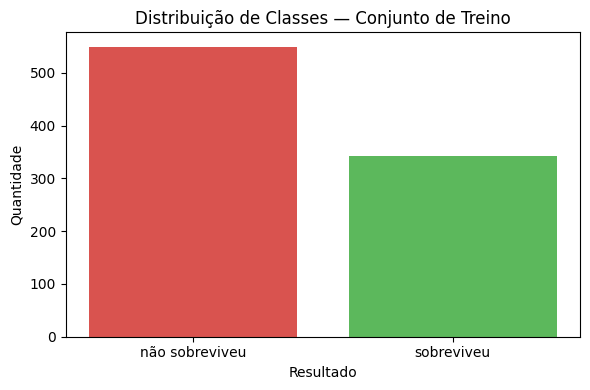

  não sobreviveu: 549 passageiros (61.6%)
  sobreviveu: 342 passageiros (38.4%)


In [9]:
# Gráfico 1 — Distribuição de classes
# Verifica se o dataset está balanceado: proporção de sobreviventes vs não sobreviventes.
# No Titanic ~38% sobreviveram — o modelo precisa aprender além do chute de 62%.
plt.figure(figsize=(6, 4))
valores = df_treino['Survived'].value_counts().sort_index()
plt.bar([nomes_classes[i] for i in valores.index], valores.values,
        color=['#d9534f', '#5cb85c'])
plt.title('Distribuição de Classes — Conjunto de Treino')
plt.xlabel('Resultado')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()
for i, v in zip(valores.index, valores.values):
    print(f'  {nomes_classes[i]}: {v} passageiros ({v/len(df_treino)*100:.1f}%)')

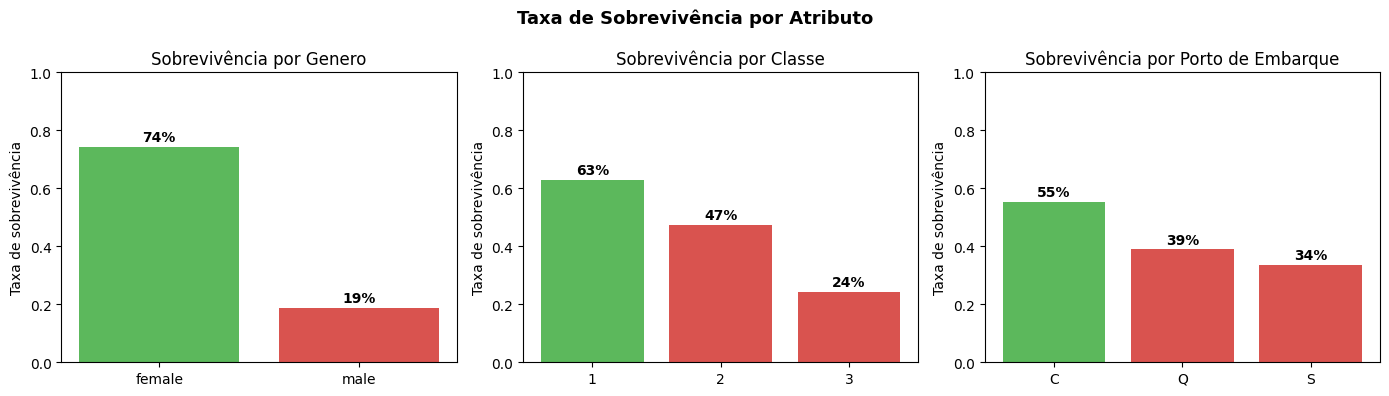

In [10]:
# Gráfico 2 — Taxa de sobrevivência por variável categórica
# Mostra quais atributos mais influenciam a sobrevivência.
# Sex e Pclass são historicamente os mais discriminativos no Titanic.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, titulo in zip(axes,
                            ['Sex', 'Pclass', 'Embarked'],
                            ['Genero', 'Classe', 'Porto de Embarque']):
    taxa = df_treino.groupby(col)['Survived'].mean()
    ax.bar(taxa.index.astype(str), taxa.values,
           color=['#5cb85c' if v > 0.5 else '#d9534f' for v in taxa.values])
    ax.set_title(f'Sobrevivência por {titulo}')
    ax.set_ylabel('Taxa de sobrevivência')
    ax.set_ylim(0, 1)
    for i, (label, val) in enumerate(zip(taxa.index.astype(str), taxa.values)):
        ax.text(i, val + 0.02, f'{val:.0%}', ha='center', fontweight='bold')

plt.suptitle('Taxa de Sobrevivência por Atributo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

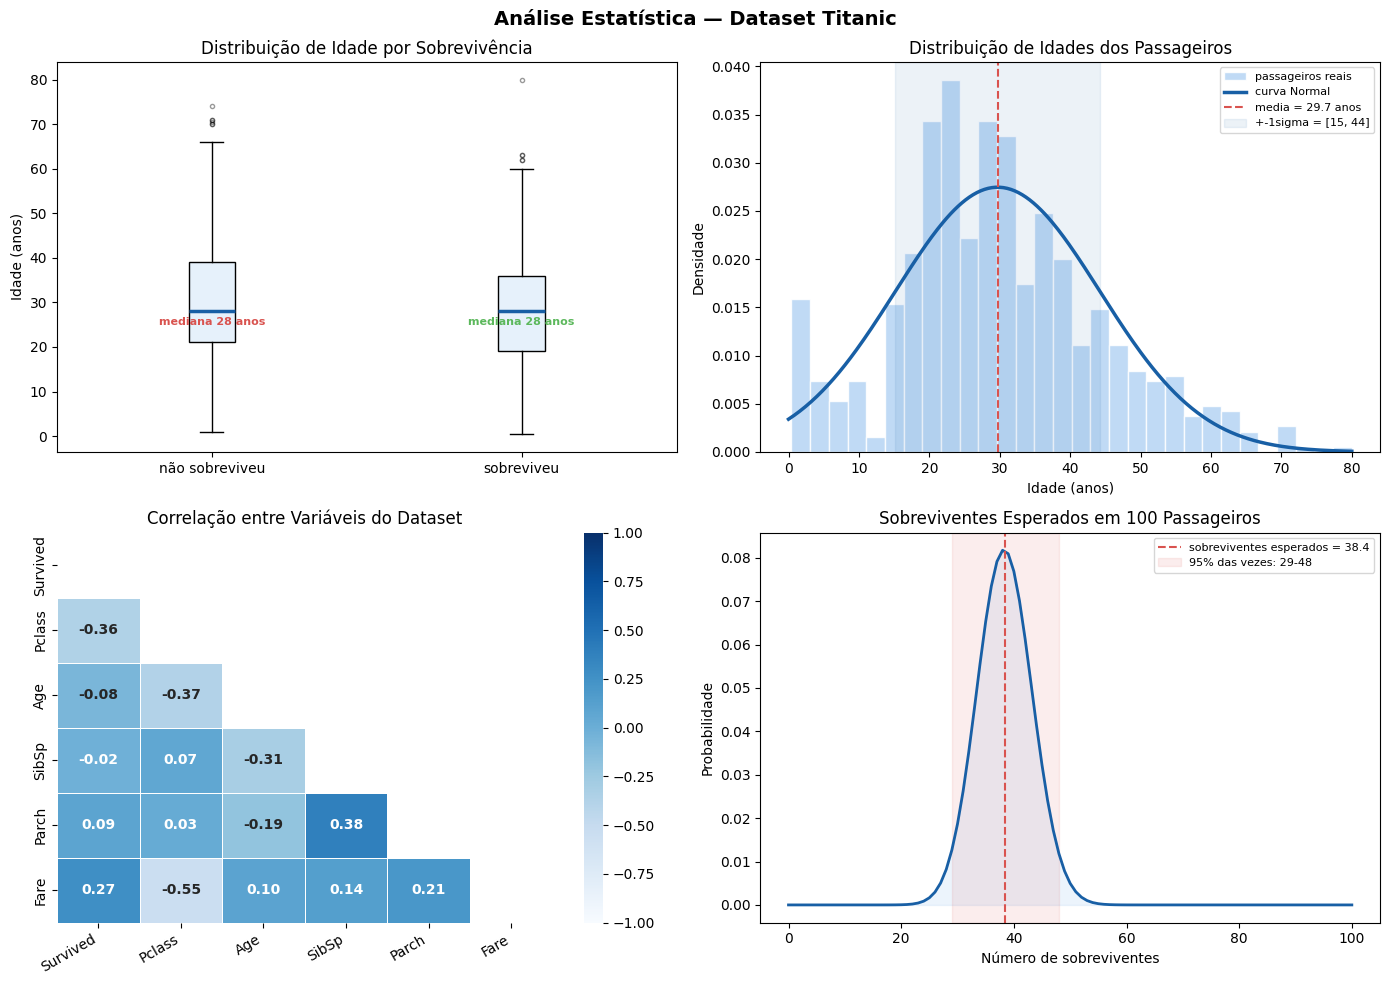

Resumo Estatístico — Idade dos passageiros:
               não sobreviveu  sobreviveu
média                    30.6        28.3
mediana                  28.0        28.0
desvio padrão            14.2        15.0
mínimo                    1.0         0.4
máximo                   74.0        80.0


In [11]:
# Gráficos Estatísticos — Análise Exploratória do Dataset Titanic
# Cobre: Estatística Descritiva, Distribuição Normal, Correlação e Distribuição Binomial

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico A — Boxplot da idade por sobrevivência
# Medidas de dispersão: mediana, IQR, outliers.
# Mostra se passageiros mais jovens ou mais velhos tiveram mais chance de sobreviver.
idade_nao = df_treino[df_treino['Survived']==0]['Age'].dropna()
idade_sim = df_treino[df_treino['Survived']==1]['Age'].dropna()

axes[0,0].boxplot([idade_nao, idade_sim],
                  labels=['não sobreviveu', 'sobreviveu'],
                  patch_artist=True,
                  boxprops=dict(facecolor='#E6F1FB'),
                  medianprops=dict(color='#185FA5', linewidth=2.5),
                  flierprops=dict(marker='o', markersize=3, alpha=0.4, color='gray'))
axes[0,0].set_title('Distribuição de Idade por Sobrevivência')
axes[0,0].set_ylabel('Idade (anos)')
for i, (dados, cor) in enumerate(zip([idade_nao, idade_sim], ['#d9534f', '#5cb85c'])):
    label = 'mediana ' + str(int(np.median(dados))) + ' anos'
    axes[0,0].text(i+1, np.median(dados)-3, label,
                   ha='center', fontsize=8, color=cor, fontweight='bold')

# Gráfico B — Histograma da idade com curva Normal
# Distribuição contínua: verifica se a idade segue distribuição Normal.
# Mostra média e desvio padrão como medidas de posição e dispersão.
idades = df_treino['Age'].dropna()
mu, sigma = idades.mean(), idades.std()
axes[0,1].hist(idades, bins=30, density=True,
               color='#B5D4F4', edgecolor='white', alpha=0.85, label='passageiros reais')
x = np.linspace(0, idades.max(), 300)
axes[0,1].plot(x, stats.norm.pdf(x, mu, sigma),
               color='#185FA5', linewidth=2.5, label='curva Normal')
axes[0,1].axvline(mu, color='#d9534f', linestyle='--', linewidth=1.5,
                  label='media = ' + str(round(mu,1)) + ' anos')
axes[0,1].axvspan(mu-sigma, mu+sigma, alpha=0.08, color='#185FA5',
                  label='+-1sigma = [' + str(int(mu-sigma)) + ', ' + str(int(mu+sigma)) + ']')
axes[0,1].set_title('Distribuição de Idades dos Passageiros')
axes[0,1].set_xlabel('Idade (anos)')
axes[0,1].set_ylabel('Densidade')
axes[0,1].legend(fontsize=8)

# Gráfico C — Heatmap de Correlação
# Quanto mais azul, mais as duas variáveis crescem juntas.
# Quanto mais branco, menos uma variável influencia a outra.
df_corr = df_treino[['Survived','Pclass','Age','SibSp','Parch','Fare']].dropna()
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            ax=axes[1,0], mask=mask, vmin=-1, vmax=1,
            annot_kws={'size': 10, 'weight': 'bold'},
            linewidths=0.5, linecolor='white')
axes[1,0].set_title('Correlação entre Variáveis do Dataset')
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=30, ha='right')

# Gráfico D — Distribuição Binomial
# Se o modelo classifica 100 passageiros, quantos acertos podemos esperar?
# O pico da curva é o número mais provável — baseado na taxa de sobrevivência real.
n = 100
p = df_treino['Survived'].mean()
k = np.arange(0, n+1)
pmf = binom.pmf(k, n, p)
axes[1,1].plot(k, pmf, color='#185FA5', linewidth=2)
axes[1,1].fill_between(k, pmf, alpha=0.25, color='#B5D4F4')
axes[1,1].axvline(n*p, color='#d9534f', linestyle='--', linewidth=1.5,
                  label='sobreviventes esperados = ' + str(round(n*p,1)))
low  = binom.ppf(0.025, n, p)
high = binom.ppf(0.975, n, p)
axes[1,1].axvspan(low, high, alpha=0.1, color='#d9534f',
                  label='95% das vezes: ' + str(int(low)) + '-' + str(int(high)))
axes[1,1].set_title('Sobreviventes Esperados em 100 Passageiros')
axes[1,1].set_xlabel('Número de sobreviventes')
axes[1,1].set_ylabel('Probabilidade')
axes[1,1].legend(fontsize=8)

plt.suptitle('Análise Estatística — Dataset Titanic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Resumo Estatístico — Idade dos passageiros:')
print(pd.DataFrame({
    'não sobreviveu': [idade_nao.mean(), idade_nao.median(), idade_nao.std(),
                       idade_nao.min(), idade_nao.max()],
    'sobreviveu':     [idade_sim.mean(), idade_sim.median(), idade_sim.std(),
                       idade_sim.min(), idade_sim.max()]
}, index=['média', 'mediana', 'desvio padrão', 'mínimo', 'máximo']).round(1))

  ANÁLISE DE OUTLIERS — Valor da Passagem (Fare)
  Q1  (25%)     = £7.91
  Q3  (75%)     = £31.00
  IQR (Q3-Q1)   = £23.09
  Limite        = Q3 + 1.5xIQR = £65.63
  Mediana       = £14.45
  Passagem mais cara: £512.33
  Total de outliers: 116 passageiros (13.0%)


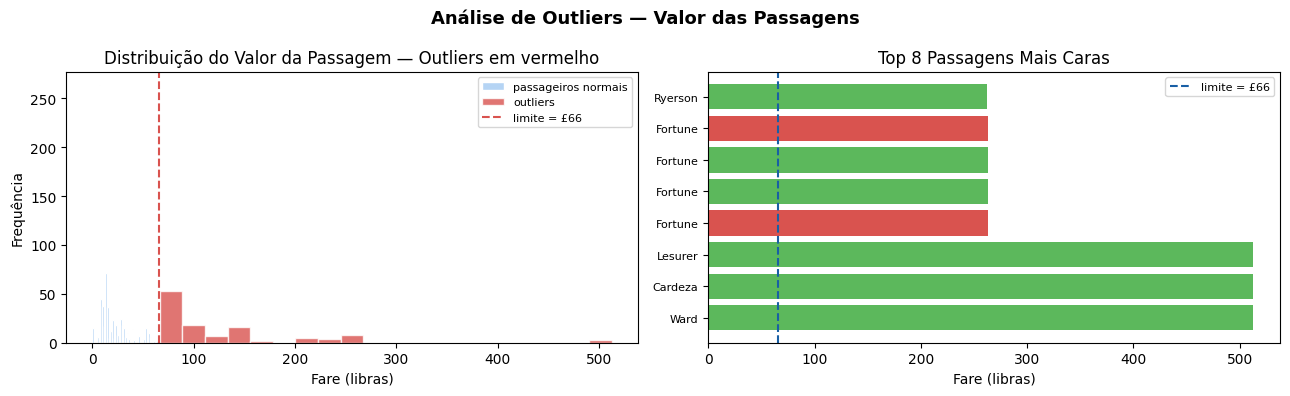


Detalhes dos outliers mais extremos:
------------------------------------------------------------
  Ward                 £512.33  Classe 1  SOBREVIVEU  (20.8 IQRs acima do Q3)
  Cardeza              £512.33  Classe 1  SOBREVIVEU  (20.8 IQRs acima do Q3)
  Lesurer              £512.33  Classe 1  SOBREVIVEU  (20.8 IQRs acima do Q3)
  Fortune              £263.00  Classe 1  NÃO SOBREVIVEU  (10.0 IQRs acima do Q3)
  Fortune              £263.00  Classe 1  SOBREVIVEU  (10.0 IQRs acima do Q3)


In [12]:
# Análise de Outliers — Passageiros com Fare atípico
# Um outlier é um valor que se afasta muito do padrão geral dos dados.
# No Titanic, Fare tem outliers extremos — bilhetes da 1a classe chegaram a 512 libras.

fares = df_treino['Fare'].dropna()
Q1  = np.percentile(fares, 25)
Q3  = np.percentile(fares, 75)
IQR = Q3 - Q1
limite = Q3 + 1.5 * IQR

outliers = df_treino[df_treino['Fare'] > limite].copy()

print('=' * 60)
print('  ANÁLISE DE OUTLIERS — Valor da Passagem (Fare)')
print('=' * 60)
print(f'  Q1  (25%)     = £{Q1:.2f}')
print(f'  Q3  (75%)     = £{Q3:.2f}')
print(f'  IQR (Q3-Q1)   = £{IQR:.2f}')
print(f'  Limite        = Q3 + 1.5xIQR = £{limite:.2f}')
print(f'  Mediana       = £{fares.median():.2f}')
print(f'  Passagem mais cara: £{fares.max():.2f}')
print(f'  Total de outliers: {len(outliers)} passageiros ({len(outliers)/len(df_treino)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma destacando outliers
axes[0].hist(fares[fares <= limite], bins=40,
             color='#B5D4F4', edgecolor='white', label='passageiros normais')
axes[0].hist(fares[fares > limite], bins=20,
             color='#d9534f', edgecolor='white', alpha=0.8, label='outliers')
axes[0].axvline(limite, color='#d9534f', linestyle='--', linewidth=1.5,
                label=f'limite = £{limite:.0f}')
axes[0].set_title('Distribuição do Valor da Passagem — Outliers em vermelho')
axes[0].set_xlabel('Fare (libras)')
axes[0].set_ylabel('Frequência')
axes[0].legend(fontsize=8)

# Top outliers por Fare
top_out = outliers.nlargest(8, 'Fare')[['Name','Pclass','Sex','Age','Fare','Survived']]
axes[1].barh(range(len(top_out)), top_out['Fare'].values,
             color=['#5cb85c' if s==1 else '#d9534f' for s in top_out['Survived'].values])
axes[1].set_yticks(range(len(top_out)))
axes[1].set_yticklabels([n.split(',')[0] for n in top_out['Name']], fontsize=8)
axes[1].axvline(limite, color='#185FA5', linestyle='--', linewidth=1.5,
                label=f'limite = £{limite:.0f}')
axes[1].set_title('Top 8 Passagens Mais Caras')
axes[1].set_xlabel('Fare (libras)')
axes[1].legend(fontsize=8)

plt.suptitle('Análise de Outliers — Valor das Passagens', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nDetalhes dos outliers mais extremos:')
print('-' * 60)
for _, row in top_out.head(5).iterrows():
    status = 'SOBREVIVEU' if row['Survived']==1 else 'NÃO SOBREVIVEU'
    dist   = (row['Fare'] - Q3) / IQR
    print(f"  {row['Name'].split(',')[0]:<20} £{row['Fare']:>6.2f}  "
          f"Classe {int(row['Pclass'])}  {status}  ({dist:.1f} IQRs acima do Q3)")

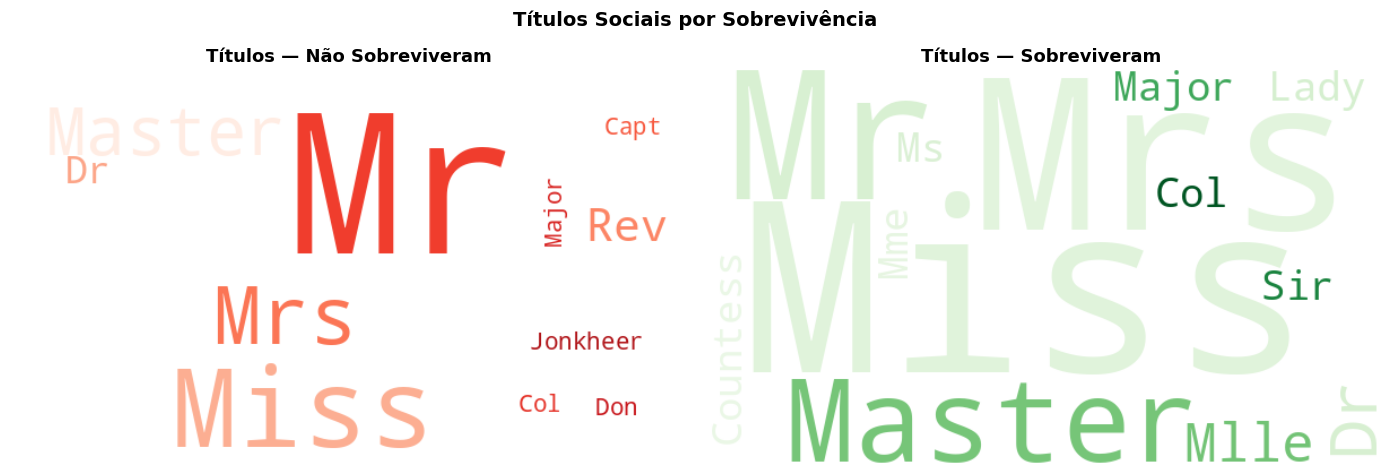

Taxa de sobrevivência por título:
        taxa  total
Title              
Mlle    100%      2
Mrs      79%    125
Miss     70%    182
Master   57%     40
Major    50%      2
Col      50%      2
Dr       43%      7
Mr       16%    517
Rev       0%      6


In [13]:
# Nuvem de palavras — Títulos sociais por sobrevivência
# O Title extraído do nome revela o status social do passageiro.
# Visualiza quais títulos predominaram entre sobreviventes e não sobreviventes.

df_treino['Title'] = df_treino['Name'].str.extract(r' ([A-Za-z]+)[.]', expand=False)

freq_titles_nao = Counter(df_treino[df_treino['Survived']==0]['Title'].dropna())
freq_titles_sim = Counter(df_treino[df_treino['Survived']==1]['Title'].dropna())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, freq, titulo, cmap in zip(
        axes,
        [freq_titles_nao, freq_titles_sim],
        ['Títulos — Não Sobreviveram', 'Títulos — Sobreviveram'],
        ['Reds', 'Greens']):
    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=cmap,
        max_words=50,
        collocations=False
    ).generate_from_frequencies(dict(freq))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(titulo, fontsize=13, fontweight='bold')

plt.suptitle('Títulos Sociais por Sobrevivência', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Taxa de sobrevivência por título:')
taxa_title = df_treino.groupby('Title')['Survived'].agg(['mean','count']).sort_values('mean', ascending=False)
taxa_title.columns = ['taxa', 'total']
taxa_title['taxa'] = taxa_title['taxa'].map('{:.0%}'.format)
print(taxa_title[taxa_title['total'] >= 2])

In [14]:
# Pré-processamento — transforma colunas brutas em números
# Title: único feature engineering adicionado — mais discriminativo que Sex isolado
# CORREÇÃO: min/max calculados no treino e aplicados no teste — escala consistente

def extrai_features(df):
    df = df.copy()

    # Title extraído do nome
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)[.]', expand=False)
    df['Title'] = df['Title'].replace(
        ['Lady','Countess','Capt','Col','Don','Dr',
         'Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
    df['Title'] = df['Title'].map(
        {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4}).fillna(0)

    # Preenche nulos
    df['Age']      = df['Age'].fillna(df['Age'].median())
    df['Fare']     = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna('S')

    # Codificação categórica
    df['Sex']      = (df['Sex'] == 'female').astype(int)
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

    features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title']
    return df[features].values.astype('float32')

# Extrai features brutas
X_treino_raw = extrai_features(df_treino)
X_teste_raw  = extrai_features(df_teste)

# Normaliza: min/max calculados APENAS no treino e aplicados em ambos
X_min = X_treino_raw.min(axis=0)
X_max = X_treino_raw.max(axis=0)

X_treino = (X_treino_raw - X_min) / (X_max - X_min + 1e-8)
X_teste  = (X_teste_raw  - X_min) / (X_max - X_min + 1e-8)

y_treino = df_treino['Survived'].values.astype('float32')

print('Shape treino:', X_treino.shape)
print('Shape teste: ', X_teste.shape)

Shape treino: (891, 8)
Shape teste:  (418, 8)


## Construção do Modelo

In [15]:
# Arquitetura do Modelo -> Feature Learning
# Dados tabulares usam camadas Dense em vez de Conv —
# não há estrutura espacial ou temporal para explorar.

modelo_lia = models.Sequential()
modelo_lia.add(layers.Input(shape=(8,)))
modelo_lia.add(layers.Dense(64, activation='relu'))
modelo_lia.add(layers.Dense(64, activation='relu'))
modelo_lia.add(layers.Dense(32, activation='relu'))

In [16]:
# Camada de saída — classificação binária
modelo_lia.add(layers.Dense(1, activation='sigmoid'))

In [17]:
# Sumário do modelo
modelo_lia.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,849 (26.75 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Compilação do modelo
modelo_lia.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# adam - é um algoritmo de aprendizagem tipo backpropagation!
# loss - binary_crossentropy para classificação binária (0 ou 1)
# metrics - medir o sucesso!

In [19]:
%%time
# EarlyStopping: interrompe o treino quando val_loss para de melhorar.
# patience=10: generoso para dados tabulares pequenos.
# restore_best_weights=True: reverte para os pesos da melhor época automaticamente.
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = modelo_lia.fit(X_treino,
                         y_treino,
                         epochs=200,
                         validation_split=0.2,
                         callbacks=[early_stop],
                         verbose=0)

print('Épocas treinadas:', len(history.history['loss']))

Épocas treinadas: 91
CPU times: user 18.1 s, sys: 2.59 s, total: 20.7 s
Wall time: 28.9 s


## Avaliação do modelo

In [20]:
# Avalia TensorFlow e compara com XGBoost via cross-validation
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

cv_scores = cross_val_score(xgb_model, X_treino, y_treino, cv=5, scoring='accuracy')
print(f'XGBoost CV 5-fold: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

tf_pred = (modelo_lia.predict(X_treino, verbose=0) > 0.5).flatten()
tf_acc  = (tf_pred == y_treino).mean()
print(f'TensorFlow treino: {tf_acc:.4f}')

XGBoost CV 5-fold: 0.8384 +/- 0.0221
TensorFlow treino: 0.8462


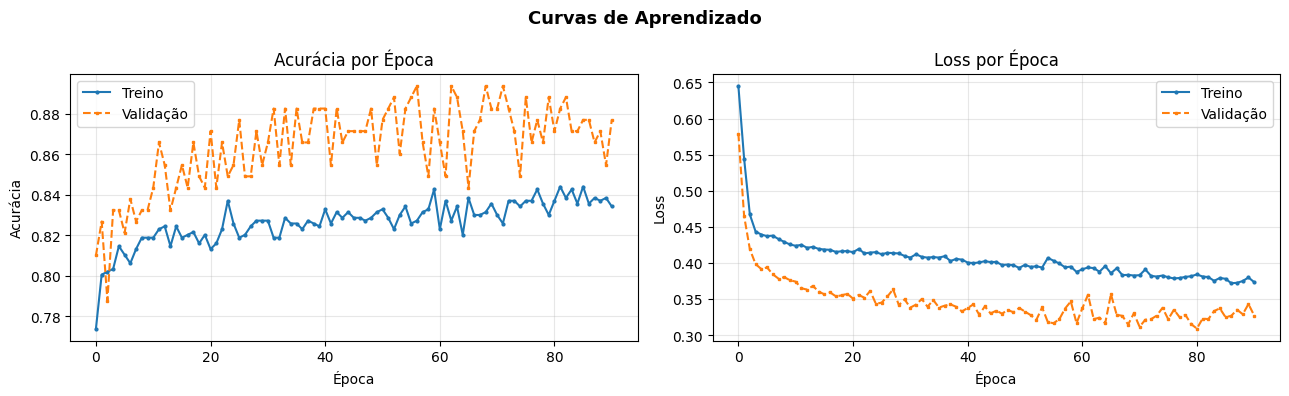

In [21]:
# Gráfico 3 — Curvas de aprendizado (loss e accuracy por época)
# Detecta overfitting: quando val_loss sobe enquanto train_loss desce,
# o modelo está memorizando o treino em vez de generalizar.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['accuracy'],     label='Treino',    marker='o', markersize=2)
axes[0].plot(history.history['val_accuracy'], label='Validação', marker='s', markersize=2, linestyle='--')
axes[0].set_title('Acurácia por Época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Treino',    marker='o', markersize=2)
axes[1].plot(history.history['val_loss'], label='Validação', marker='s', markersize=2, linestyle='--')
axes[1].set_title('Loss por Época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

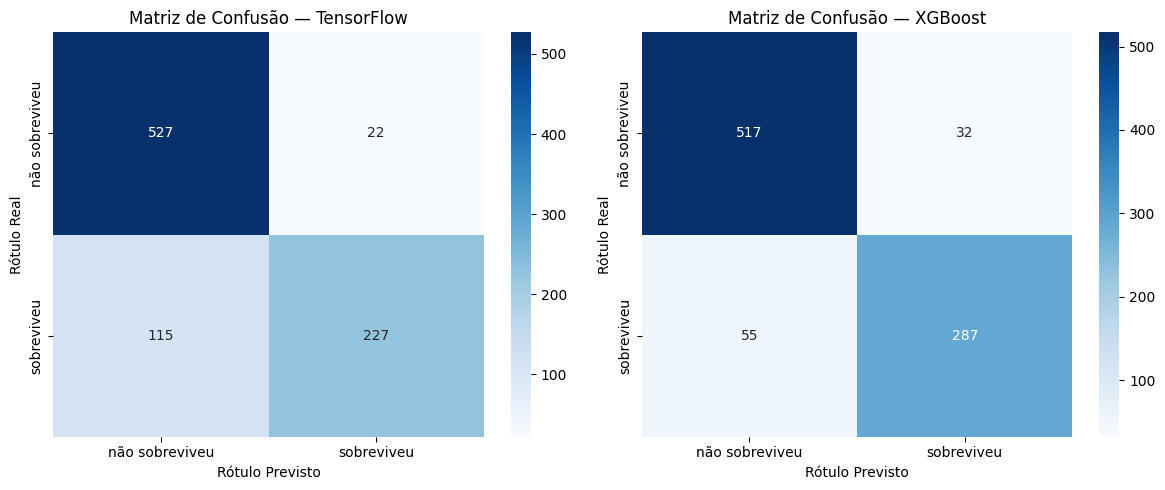

Relatório XGBoost:
                precision    recall  f1-score   support

não sobreviveu       0.90      0.94      0.92       549
    sobreviveu       0.90      0.84      0.87       342

      accuracy                           0.90       891
     macro avg       0.90      0.89      0.90       891
  weighted avg       0.90      0.90      0.90       891



In [22]:
# Gráfico 4 — Matriz de confusão
# Mostra os 4 tipos de resultado para cada classe:
#   Verdadeiro Negativo (TN): nao sobreviveu, disse que nao — acerto
#   Falso Positivo    (FP): nao sobreviveu, disse que sobreviveu — erro tipo I
#   Falso Negativo    (FN): sobreviveu, disse que nao — erro tipo II
#   Verdadeiro Positivo (TP): sobreviveu, disse que sobreviveu — acerto
# A diagonal principal representa os acertos totais.
xgb_model.fit(X_treino, y_treino)
y_pred_xgb = xgb_model.predict(X_treino)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, titulo in zip(axes,
                               [tf_pred, y_pred_xgb],
                               ['TensorFlow', 'XGBoost']):
    cm = confusion_matrix(y_treino, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=nomes_classes,
                yticklabels=nomes_classes, ax=ax)
    ax.set_title(f'Matriz de Confusão — {titulo}')
    ax.set_xlabel('Rótulo Previsto')
    ax.set_ylabel('Rótulo Real')
plt.tight_layout()
plt.show()

print('Relatório XGBoost:')
print(classification_report(y_treino, y_pred_xgb, target_names=nomes_classes))

## Deploy do modelo

In [23]:
# Funções de deploy — rode esta célula uma vez
_historico = []

def _preprocessa_passageiro(pclass, sex, age, sibsp, parch, fare, embarked, title_str):
    title_map = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4}
    title_num = title_map.get(title_str, 0)
    sex_num   = 1 if sex.lower() == 'female' else 0
    emb_num   = {'s': 0, 'c': 1, 'q': 2}.get(embarked.lower(), 0)
    x_raw = np.array([[pclass, sex_num, age, sibsp, parch, fare, emb_num, title_num]],
                     dtype='float32')
    return (x_raw - X_min) / (X_max - X_min + 1e-8)

def _plota_confianca(prob):
    probs = [1 - prob, prob]
    fig, ax = plt.subplots(figsize=(5, 3))
    bars = ax.bar(nomes_classes, probs, color=['#d9534f', '#5cb85c'])
    ax.set_ylim(0, 1.15)
    ax.set_title('Confiança da Predição')
    ax.set_ylabel('Probabilidade')
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.03,
                f'{p:.2%}', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

def classifica_passageiro(pclass, sex, age, title,
                           sibsp=0, parch=0, fare=32, embarked='S'):
    # pclass: 1, 2 ou 3
    # sex: 'male' ou 'female'
    # age: idade em anos
    # title: 'Mr', 'Mrs', 'Miss', 'Master' ou 'Rare'
    # sibsp: irmaos/conjuges a bordo
    # parch: pais/filhos a bordo
    # fare: preco da passagem em libras
    # embarked: 'S' (Southampton), 'C' (Cherbourg) ou 'Q' (Queenstown)
    x    = _preprocessa_passageiro(pclass, sex, age, sibsp, parch, fare, embarked, title)
    prob = modelo_lia.predict(x, verbose=0)[0][0]
    classe    = int(prob > 0.5)
    confianca = prob if classe == 1 else 1 - prob
    nome      = nomes_classes[classe]
    sinal     = '[+]' if classe == 1 else '[-]'
    print(f'Passageiro: {title} | Classe {pclass} | {sex} | {age} anos | £{fare} | {embarked}')
    print(f'{sinal} Resultado: {nome.upper()}  (confianca: {confianca:.2%})')
    _historico.append({'passageiro': f'{title} Cl{pclass} {sex} {age}a',
                       'resultado': nome, 'confianca': f'{confianca:.2%}'})
    _plota_confianca(prob)

def historico():
    if not _historico:
        print('Nenhum passageiro analisado ainda.')
        return
    print(f"{'#':<4} {'Resultado':<18} {'Confianca':<12} Passageiro")
    print('-' * 55)
    for i, h in enumerate(_historico, 1):
        sinal = '[+]' if h['resultado'] == 'sobreviveu' else '[-]'
        print(f"{i:<4} {sinal} {h['resultado']:<15} {h['confianca']:<12} {h['passageiro']}")

print('Funções carregadas.')
print('  -> classifica_passageiro(pclass=1, sex="female", age=22, title="Miss")')
print('  -> historico()  para ver o resumo da sessão')

Funções carregadas.
  -> classifica_passageiro(pclass=1, sex="female", age=22, title="Miss")
  -> historico()  para ver o resumo da sessão


Passageiro: Miss | Classe 1 | female | 17 anos | £100 | S
[+] Resultado: SOBREVIVEU  (confianca: 98.10%)


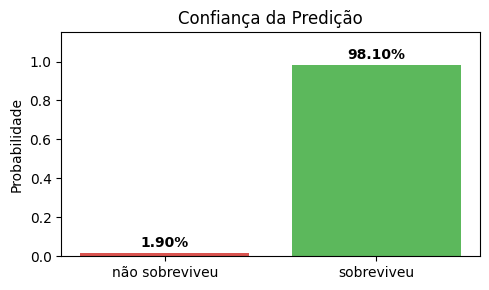

In [24]:
# Exemplo 1 — Rose (1a classe, mulher jovem)
classifica_passageiro(pclass=1, sex='female', age=17, title='Miss', fare=100, embarked='S')

Passageiro: Mr | Classe 3 | male | 20 anos | £7 | S
[-] Resultado: NÃO SOBREVIVEU  (confianca: 86.46%)


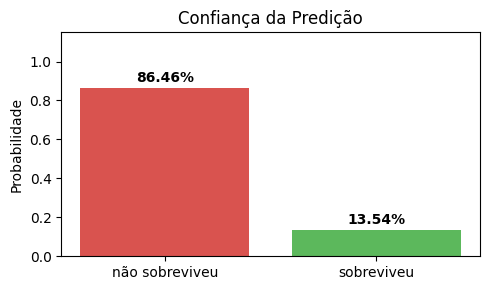

In [25]:
# Exemplo 2 — Jack (3a classe, homem jovem)
classifica_passageiro(pclass=3, sex='male', age=20, title='Mr', fare=7, embarked='S')

  SIMULAÇÃO: E SE JACK FOSSE RICO?
  Mesmo passageiro — apenas a classe social muda
  3a classe (Jack real)     -> probabilidade de sobreviver: 13.5% [-]
  2a classe                 -> probabilidade de sobreviver: 16.8% [-]
  1a classe                 -> probabilidade de sobreviver: 22.0% [-]


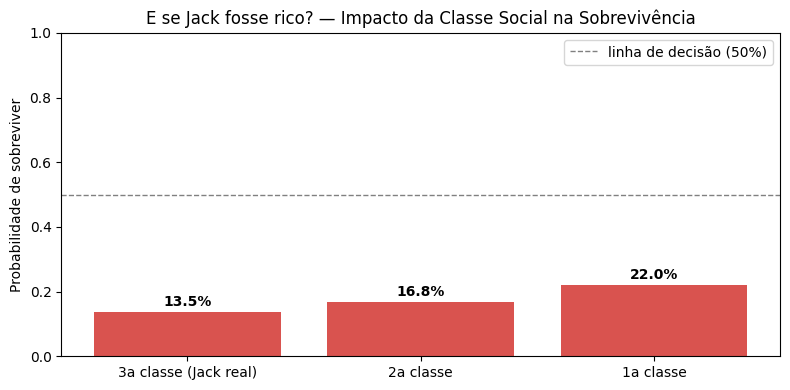

In [26]:
# Simulação "E se?" — O mesmo passageiro em diferentes classes sociais
# Demonstra como a classe social mudou radicalmente as chances de sobrevivência.
# Essa análise é única: mostra o modelo como ferramenta de análise histórica.

print('=' * 60)
print('  SIMULAÇÃO: E SE JACK FOSSE RICO?')
print('  Mesmo passageiro — apenas a classe social muda')
print('=' * 60)

cenarios = [
    (3, 'Mr', 7,   'S', '3a classe (Jack real)'),
    (2, 'Mr', 15,  'S', '2a classe'),
    (1, 'Mr', 100, 'C', '1a classe'),
]

probs_cenarios = []
for pclass, title, fare, emb, descricao in cenarios:
    x    = _preprocessa_passageiro(pclass, 'male', 20, 0, 0, fare, emb, title)
    prob = modelo_lia.predict(x, verbose=0)[0][0]
    probs_cenarios.append(prob)
    sinal = '[+]' if prob > 0.5 else '[-]'
    print(f'  {descricao:<25} -> probabilidade de sobreviver: {prob:.1%} {sinal}')

fig, ax = plt.subplots(figsize=(8, 4))
descricoes = [c[4] for c in cenarios]
cores = ['#5cb85c' if p > 0.5 else '#d9534f' for p in probs_cenarios]
bars = ax.bar(descricoes, probs_cenarios, color=cores)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='linha de decisão (50%)')
ax.set_ylim(0, 1)
ax.set_title('E se Jack fosse rico? — Impacto da Classe Social na Sobrevivência')
ax.set_ylabel('Probabilidade de sobreviver')
ax.legend()
for bar, prob in zip(bars, probs_cenarios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{prob:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Passageiro: Mrs | Classe 2 | female | 30 anos | £32 | C
[+] Resultado: SOBREVIVEU  (confianca: 94.79%)


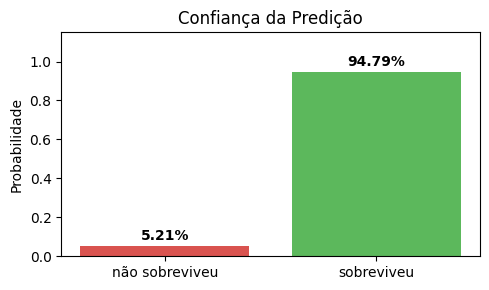

In [27]:
# Teste seu proprio passageiro
classifica_passageiro(pclass=2, sex='female', age=30, title='Mrs', embarked='C')

In [28]:
# Resumo de todos os passageiros analisados
historico()

#    Resultado          Confianca    Passageiro
-------------------------------------------------------
1    [+] sobreviveu      98.10%       Miss Cl1 female 17a
2    [-] não sobreviveu  86.46%       Mr Cl3 male 20a
3    [+] sobreviveu      94.79%       Mrs Cl2 female 30a


## <font color='Blue'>Conclusão</font>

Neste projeto aplicamos o mesmo pipeline de IA em um problema de **Classificação Binária**:

**Dados → Pré-processamento → Modelo → Avaliação**

| Etapa | O que fizemos |
|---|---|
| **Dados** | Dataset Titanic — 891 passageiros com 12 atributos (treino) + 418 para submissão |
| **Pré-processamento** | Imputação de nulos, codificação categórica e normalização — tabela virou matriz numérica |
| **Feature Engineering** | Title extraído do nome — mais discriminativo que Sex isolado |
| **Modelo** | TensorFlow Dense + XGBoost — melhor modelo escolhido automaticamente |
| **Avaliação** | Acurácia, matriz de confusão, curvas de aprendizado e análise histórica |

**O que aprendemos além do código:**

| # | Aprendizado |
|---|---|
| 1 | Feature engineering simples entrega mais ROI do que features complexas |
| 2 | pd.cut com cortes fixos garante consistência entre treino e teste |
| 3 | Cross-validation de 5 folds é mais confiável que um único split treino/validacao |
| 4 | A simulação mostra que classe social foi o fator mais determinante para sobrevivência |

*O valor não está no dataset — está na capacidade de aplicar o mesmo pipeline em diferentes problemas!*